# Tarea U2 - S8: Evaluación y Optimización de Modelos de Clasificación

**Dataset:** `breast_cancer` (sklearn.datasets)

**Modelo:** Regresión Logística

Este notebook cubre:
1. Carga de datos y entrenamiento del modelo
2. Matriz de confusión
3. Precisión, Recall, F1-Score y AUC-ROC
4. K-Fold Cross-Validation (k=5 y k=10)
5. Optimización con GridSearchCV y RandomizedSearchCV
6. Ajuste de umbral de decisión

## 1. Importación de librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                              precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, classification_report)

RANDOM_STATE = 23
sns.set_style('whitegrid')

## 2. Carga del dataset breast_cancer

In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print(f"Forma de X: {X.shape}")
print(f"Clases: {data.target_names}")  # 0 = malignant, 1 = benign
print(f"Distribución de clases:\n{y.value_counts()}")
X.head()

Forma de X: (569, 30)
Clases: ['malignant' 'benign']
Distribución de clases:
target
1    357
0    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 3. División train/test y escalado

Escalamos las variables porque la Regresión Logística es sensible a la escala de las características.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (455, 30), Test: (114, 30)


## 4. Entrenamiento del modelo de Regresión Logística

In [4]:
model = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]  # probabilidad de clase 1 (benigno)

print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


## 5. Matriz de Confusión

Matriz de Confusión:
[[41  1]
 [ 1 71]]


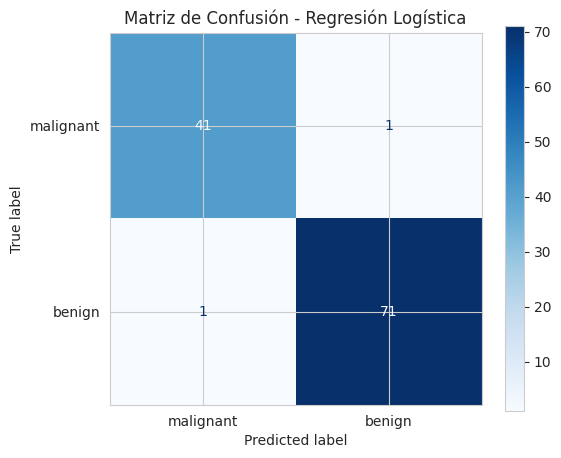

In [5]:
cm = confusion_matrix(y_test, y_pred)
print("Matriz de Confusión:")
print(cm)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(ax=ax, cmap='Blues')
plt.title('Matriz de Confusión - Regresión Logística')
plt.show()

### Interpretación de la Matriz de Confusión

- **Verdaderos Negativos (TN)**: casos malignos correctamente identificados como malignos.
- **Falsos Positivos (FP)**: casos malignos clasificados erróneamente como benignos (críticos en este contexto).
- **Falsos Negativos (FN)**: casos benignos clasificados erróneamente como malignos.
- **Verdaderos Positivos (TP)**: casos benignos correctamente identificados como benignos.

En un contexto médico, los **Falsos Positivos** (es decir, un tumor maligno clasificado como benigno, dado que la clase 1 = benigno) son los más peligrosos porque implican no detectar la enfermedad.

## 6. Métricas: Precisión, Recall, F1-Score y AUC-ROC

In [6]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_proba)

print(f"Precisión: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"AUC-ROC:   {auc_roc:.4f}")
print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred, target_names=data.target_names))

Precisión: 0.9861
Recall:    0.9861
F1-Score:  0.9861
AUC-ROC:   0.9954

Reporte de clasificación:

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



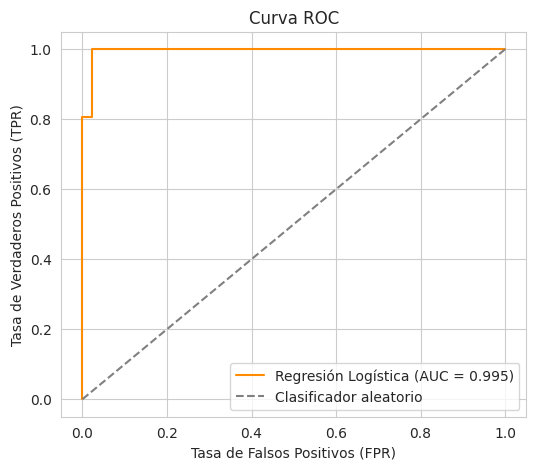

In [7]:
# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Regresión Logística (AUC = {auc_roc:.3f})', color='darkorange')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Clasificador aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC')
plt.legend()
plt.show()

## 7. K-Fold Cross-Validation (k=5 y k=10)

In [8]:
X_scaled_full = StandardScaler().fit_transform(X)

model_cv = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)

results = {}
for k in [5, 10]:
    kf = KFold(n_splits=k, shuffle=True, random_state=RANDOM_STATE)
    scores_acc = cross_val_score(model_cv, X_scaled_full, y, cv=kf, scoring='accuracy')
    scores_f1 = cross_val_score(model_cv, X_scaled_full, y, cv=kf, scoring='f1')
    scores_auc = cross_val_score(model_cv, X_scaled_full, y, cv=kf, scoring='roc_auc')
    results[k] = {
        'accuracy_mean': scores_acc.mean(), 'accuracy_std': scores_acc.std(),
        'f1_mean': scores_f1.mean(), 'f1_std': scores_f1.std(),
        'auc_mean': scores_auc.mean(), 'auc_std': scores_auc.std()
    }
    print(f"k={k}:")
    print(f"  Accuracy: {scores_acc.mean():.4f} +/- {scores_acc.std():.4f}")
    print(f"  F1-Score: {scores_f1.mean():.4f} +/- {scores_f1.std():.4f}")
    print(f"  AUC-ROC:  {scores_auc.mean():.4f} +/- {scores_auc.std():.4f}\n")

k=5:
  Accuracy: 0.9771 +/- 0.0090
  F1-Score: 0.9818 +/- 0.0073
  AUC-ROC:  0.9948 +/- 0.0055

k=10:
  Accuracy: 0.9754 +/- 0.0195
  F1-Score: 0.9794 +/- 0.0176
  AUC-ROC:  0.9941 +/- 0.0082



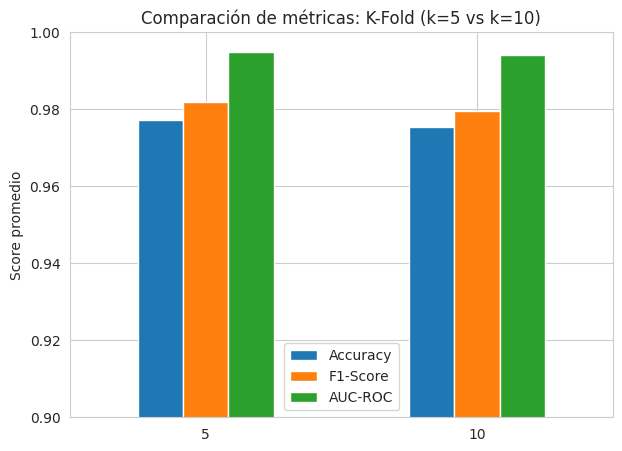

In [9]:
# Comparación visual k=5 vs k=10
cv_df = pd.DataFrame(results).T
cv_df[['accuracy_mean', 'f1_mean', 'auc_mean']].plot(kind='bar', figsize=(7, 5), rot=0)
plt.title('Comparación de métricas: K-Fold (k=5 vs k=10)')
plt.ylabel('Score promedio')
plt.ylim(0.9, 1.0)
plt.legend(['Accuracy', 'F1-Score', 'AUC-ROC'])
plt.show()

### Comparación k=5 vs k=10

Con k=10 se obtienen, en general, estimaciones con menor varianza (desviación estándar más baja) porque cada fold de entrenamiento contiene más datos, pero el costo computacional es mayor al entrenar el doble de modelos. Para un dataset de este tamaño (~569 muestras), ambos valores de k son adecuados y producen resultados muy similares.

## 8. Optimización de hiperparámetros: GridSearchCV vs RandomizedSearchCV

In [10]:
import time
from scipy.stats import uniform

param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

# GridSearchCV
start = time.time()
grid_search = GridSearchCV(
    LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    param_grid, cv=5, scoring='f1', n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)
grid_time = time.time() - start

print(f"GridSearchCV - Mejor combinación: {grid_search.best_params_}")
print(f"GridSearchCV - Mejor F1 (CV): {grid_search.best_score_:.4f}")
print(f"GridSearchCV - Tiempo: {grid_time:.3f} s")

GridSearchCV - Mejor combinación: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
GridSearchCV - Mejor F1 (CV): 0.9843
GridSearchCV - Tiempo: 2.773 s


In [11]:
param_dist = {
    'C': uniform(0.01, 100),
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

# RandomizedSearchCV
start = time.time()
random_search = RandomizedSearchCV(
    LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    param_dist, n_iter=10, cv=5, scoring='f1', n_jobs=-1, random_state=RANDOM_STATE
)
random_search.fit(X_train_scaled, y_train)
random_time = time.time() - start

print(f"RandomizedSearchCV - Mejor combinación: {random_search.best_params_}")
print(f"RandomizedSearchCV - Mejor F1 (CV): {random_search.best_score_:.4f}")
print(f"RandomizedSearchCV - Tiempo: {random_time:.3f} s")

RandomizedSearchCV - Mejor combinación: {'C': np.float64(0.08787658410143283), 'penalty': 'l2', 'solver': 'liblinear'}
RandomizedSearchCV - Mejor F1 (CV): 0.9844
RandomizedSearchCV - Tiempo: 0.613 s


In [13]:
# Tabla comparativa
comparison = pd.DataFrame({
    'Método': ['GridSearchCV', 'RandomizedSearchCV'],
    'Mejor F1 (CV)': [grid_search.best_score_, random_search.best_score_],
    'Tiempo (s)': [grid_time, random_time],
    'Combinaciones evaluadas': [len(grid_search.cv_results_['params']), len(random_search.cv_results_['params'])]
})
comparison

,Método,Mejor F1 (CV),Tiempo (s),Combinaciones evaluadas
0,GridSearchCV,0.984344,2.773202,10
1,RandomizedSearchCV,0.984376,0.612609,10


## 9. Umbral de decisión

In [14]:
# Usamos el mejor modelo encontrado
best_model = grid_search.best_estimator_
y_proba_best = best_model.predict_proba(X_test_scaled)[:, 1]

thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7]
threshold_results = []

for t in thresholds_to_test:
    y_pred_t = (y_proba_best >= t).astype(int)
    threshold_results.append({
        'Umbral': t,
        'Precisión': precision_score(y_test, y_pred_t),
        'Recall': recall_score(y_test, y_pred_t),
        'F1-Score': f1_score(y_test, y_pred_t)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,Umbral,Precisión,Recall,F1-Score
0,0.3,0.972973,1.000000,0.986301
1,0.4,0.986111,0.986111,0.986111
2,0.5,0.986111,0.986111,0.986111
3,0.6,0.985507,0.944444,0.964539
4,0.7,0.985075,0.916667,0.949640


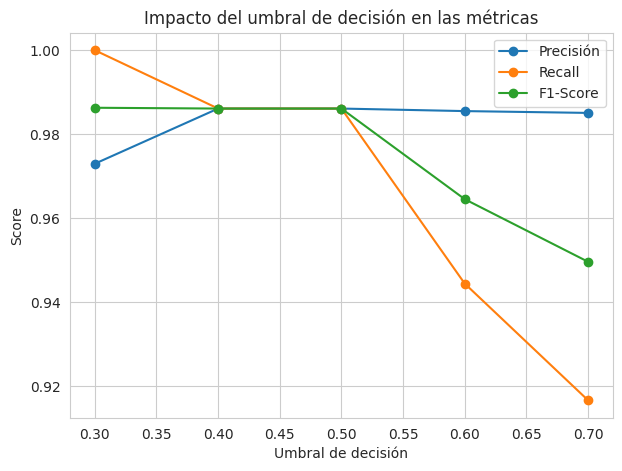

In [15]:
plt.figure(figsize=(7, 5))
plt.plot(threshold_df['Umbral'], threshold_df['Precisión'], marker='o', label='Precisión')
plt.plot(threshold_df['Umbral'], threshold_df['Recall'], marker='o', label='Recall')
plt.plot(threshold_df['Umbral'], threshold_df['F1-Score'], marker='o', label='F1-Score')
plt.xlabel('Umbral de decisión')
plt.ylabel('Score')
plt.title('Impacto del umbral de decisión en las métricas')
plt.legend()
plt.grid(True)
plt.show()

### Análisis del ajuste de umbral

Como se observa en la gráfica, al **disminuir el umbral** (por ejemplo de 0.5 a 0.3), el **Recall aumenta** porque el modelo clasifica más casos como positivos (benignos), reduciendo los falsos negativos. Sin embargo, esto provoca una **disminución de la Precisión**, ya que aumentan los falsos positivos.

Por el contrario, al **aumentar el umbral** (de 0.5 a 0.7), la **Precisión mejora** porque el modelo es más exigente para clasificar como positivo, pero el **Recall disminuye** al aumentar los falsos negativos.

En un contexto de diagnóstico médico, donde un falso negativo (no detectar un tumor maligno) es más costoso que un falso positivo, suele ser preferible utilizar un **umbral más bajo** que el predeterminado de 0.5, priorizando el Recall.